In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Housing.csv to Housing.csv


In [3]:
df = pd.read_csv("Housing.csv")

In [4]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning
0,13300000,7420,4,2,3,yes,no,no,no,yes
1,12250000,8960,4,4,4,yes,no,no,no,yes
2,12250000,9960,3,2,2,yes,no,yes,no,no
3,12215000,7500,4,2,2,yes,no,yes,no,yes
4,11410000,7420,4,1,2,yes,yes,yes,no,yes


In [5]:
df.shape

(545, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   price            545 non-null    int64 
 1   area             545 non-null    int64 
 2   bedrooms         545 non-null    int64 
 3   bathrooms        545 non-null    int64 
 4   stories          545 non-null    int64 
 5   mainroad         545 non-null    object
 6   guestroom        545 non-null    object
 7   basement         545 non-null    object
 8   hotwaterheating  545 non-null    object
 9   airconditioning  545 non-null    object
dtypes: int64(5), object(5)
memory usage: 42.7+ KB


In [9]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [10]:
df.describe()

,price,area,bedrooms,bathrooms,stories
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000


In [11]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning'],
      dtype='object')

In [13]:
binary_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning"
]

for col in binary_columns:
    df[col] = df[col].map({"yes": 1, "no": 0})

In [14]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning
0,13300000,7420,4,2,3,1,0,0,0,1
1,12250000,8960,4,4,4,1,0,0,0,1
2,12250000,9960,3,2,2,1,0,1,0,0
3,12215000,7500,4,2,2,1,0,1,0,1
4,11410000,7420,4,1,2,1,1,1,0,1


In [16]:
X = df.drop("price", axis=1)
y = df["price"]

In [17]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning
0,7420,4,2,3,1,0,0,0,1
1,8960,4,4,4,1,0,0,0,1
2,9960,3,2,2,1,0,1,0,0
3,7500,4,2,2,1,0,1,0,1
4,7420,4,1,2,1,1,1,0,1


In [18]:
y.head()

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000


In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [20]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (436, 9)
Testing Features: (109, 9)
Training Target: (436,)
Testing Target: (109,)


In [21]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [22]:
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
316,4060000,5.416967e+06
77,6650000,6.818564e+06
360,3710000,3.210479e+06
90,6440000,4.875625e+06
493,2800000,3.307045e+06
209,4900000,4.080092e+06
176,5250000,5.458604e+06
249,4543000,6.032291e+06
516,2450000,2.631205e+06
426,3353000,2.341428e+06


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)


Mean Absolute Error (MAE): 1029305.7135858475
Root Mean Squared Error (RMSE): 1413204.618503116
R² Score: 0.6048828690833074


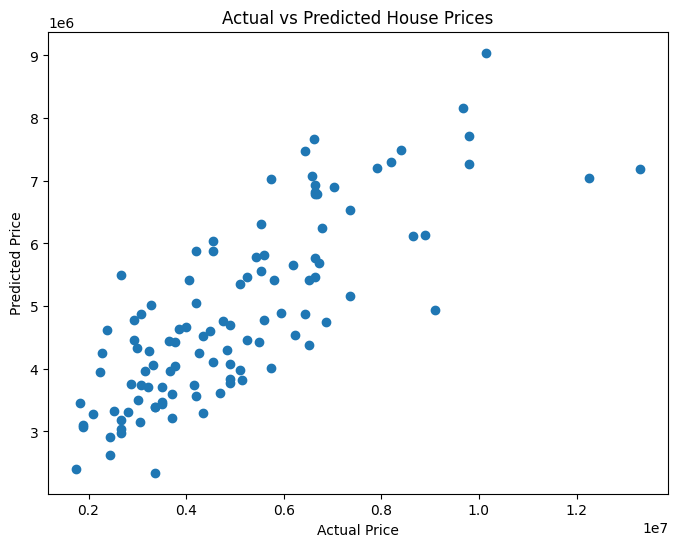

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [25]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
2,bathrooms,1.119867e+06
8,airconditioning,8.743500e+05
7,hotwaterheating,7.307012e+05
4,mainroad,6.127039e+05
6,basement,5.374749e+05
3,stories,4.029370e+05
5,guestroom,2.575018e+05
1,bedrooms,1.189729e+05
0,area,2.800897e+02


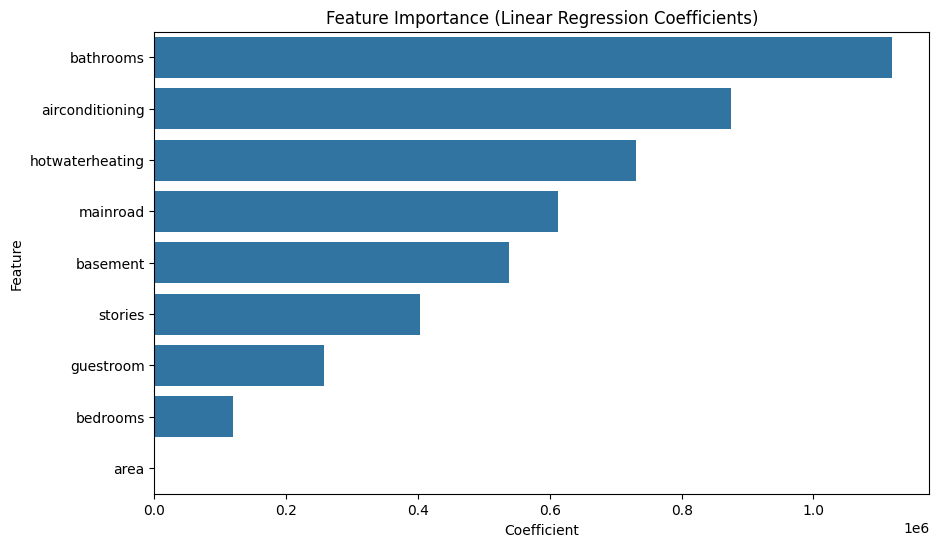

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=coefficients.sort_values(by="Coefficient", ascending=False),
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Importance (Linear Regression Coefficients)")
plt.show()

# Business Insights

1. Houses with larger areas generally have higher prices.

2. Additional bathrooms and stories positively influence house prices.

3. Features such as air conditioning and access to the main road increase the predicted value of a house.

4. The model achieved an R² score of approximately 0.60, indicating it captures many important pricing patterns, while additional features could further improve prediction accuracy.

# Conclusion

In this project, a Linear Regression model was developed to predict house prices based on various property features.

The project included:
- Data loading and exploration
- Data preprocessing
- Encoding categorical variables
- Splitting data into training and testing sets
- Training a Linear Regression model
- Making predictions
- Evaluating the model using MAE, RMSE, and R² Score

This project demonstrates the complete workflow of a beginner machine learning regression project using Python and Scikit-learn.